<a href="https://colab.research.google.com/github/isadorapandas/data-science-teste-hipoteses/blob/main/Testando_hipoteses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# carregando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# idade de aponsentadoria
dados_idade_aposentadoria = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_idade_aposentadoria.csv")

# Tempo de Vida de uma Lâmpada
dados_vida_lampada = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_vida_lampada.csv")

# Altura dos funcionarios
dados_alturas = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_alturas.csv")

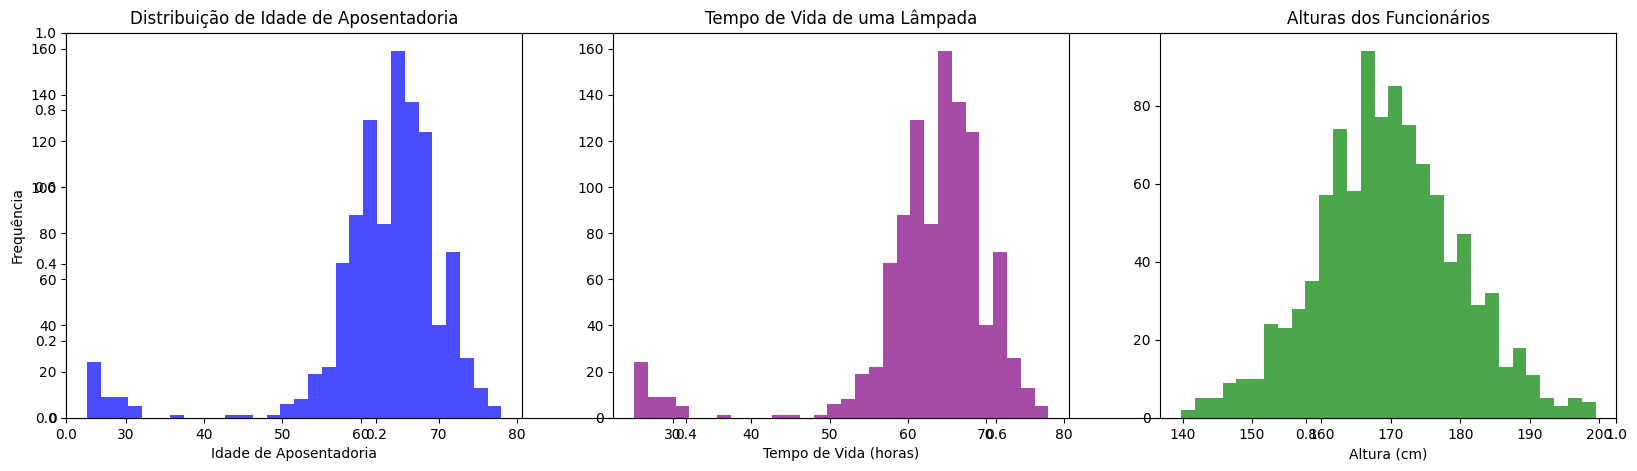

In [3]:
# Várias distribuições
plt.subplots(figsize=(20, 5))
plt.subplot(131)
plt.title('Distribuição de Idade de Aposentadoria')
plt.xlabel('Idade de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(dados_idade_aposentadoria, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(dados_vida_lampada, bins=30, alpha=0.7, color='purple')
plt.title('Tempo de Vida de uma Lâmpada')
plt.xlabel('Tempo de Vida (horas)')

plt.subplot(133)
plt.hist(dados_alturas, bins=30, alpha=0.7, color='green')
plt.title('Alturas dos Funcionários')
plt.xlabel('Altura (cm)')

plt.show()

In [4]:
from os import replace
# Reamostragens

# tamanho da amostra
n = 100

# quantidade de amostras
qnt = 100000

# função de reamostragem e cálculo de médias
def reamostragem_medias(dados, coluna, n, qnt):
    medias = [dados[coluna].sample(n, replace = True).mean()for i in range(qnt)]
    return medias

In [10]:
# Realizando as reamostragens com a função
medias_idade = reamostragem_medias(dados_idade_aposentadoria, 'idade', n, qnt)
medias_duracao = reamostragem_medias(dados_vida_lampada, 'duracao', n, qnt)
medias_altura = reamostragem_medias(dados_alturas, 'alturas', n, qnt)

In [11]:
print("*****  Médias populacionais *****")

print("idade:", dados_idade_aposentadoria['idade'].mean())
print("duracao:", dados_vida_lampada['duracao'].mean())
print("alturas:", dados_alturas['alturas'].mean())

*****  Médias populacionais *****
idade: 62.70857142857143
duracao: 1731.8036029420002
alturas: 169.52022


In [12]:
def Average(lst):
    return sum(lst) / len(lst)

print("*****  Médias amostrais *****")

print("idade:", Average(medias_idade))
print("duração:", Average(medias_duracao))
print("altura:", Average(medias_altura))


*****  Médias pamostrais *****
idade: 62.71140109999998
duração: 1731.625097858897
altura: 169.53257420899953


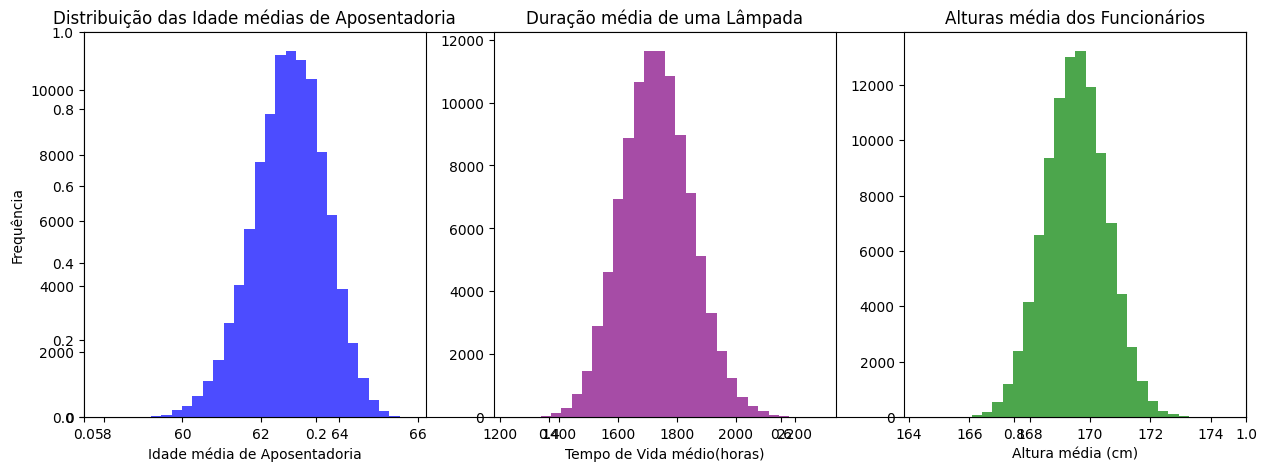

In [13]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribuição das Idade médias de Aposentadoria')
plt.xlabel('Idade média de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(medias_idade, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')

plt.subplot(133)
plt.hist(medias_altura, bins=30, alpha=0.7, color='green')
plt.title('Alturas média dos Funcionários')
plt.xlabel('Altura média (cm)')

plt.show()

In [14]:
# média da nova amostra
media_nova_amostra = 1200

In [15]:
# media original
media_populacional = dados_vida_lampada['duracao'].mean()

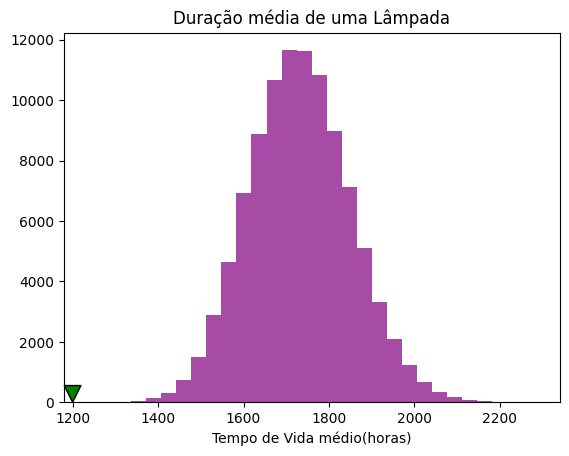

In [17]:
# Quão distante essa média está do comportamento?

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [19]:
# transformando medias_duração em DataFrame
duracao_amostras = pd.DataFrame({'medias_duracao': medias_duracao})

In [20]:
# calculando informações
media_das_medias = duracao_amostras['medias_duracao'].mean()
EP = duracao_amostras['medias_duracao'].std()

print("*****  Medidas amostrais *****")
print("média:", media_das_medias)
print("Erro Padrão:", EP )

*****  Medidas amostrais *****
média: 1731.625097858904
Erro Padrão: 118.26272789614279


In [24]:
# Quantos erros?
1732 - EP

1732 - 3*EP

# EP vai ser o nosso parâmetrp do quão longe estamos

1377.2118163115715

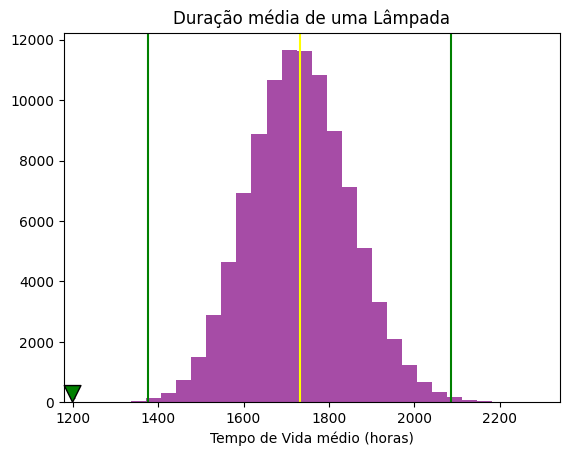

In [25]:
# Visualizando a quantidade de amostras entre 3EP +- da média.

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio (horas)')
plt.axvline(media_das_medias, color = "yellow")
plt.axvline(media_das_medias + 3*EP , color = "green")
plt.axvline(media_das_medias - 3*EP , color = "green")
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [26]:
#quanto está no intervalo de +ou- dois desvio
qnt_obs = duracao_amostras[(duracao_amostras > media_das_medias - 3*EP) &
                          (duracao_amostras < media_das_medias + 3*EP)]


In [28]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()*100

,0
medias_duracao,99.692


In [29]:
# importando o stats
from scipy import stats

In [30]:
# levar em consideração essa amostra
dados_vida_lampada

# nível de confiança definido
confianca = 0.95

In [32]:
#informações para o IC
media = dados_vida_lampada['duracao'].mean()
desvio_padrao_amostral = dados_vida_lampada['duracao'].std()
tamanho_amostra = len(dados_vida_lampada)

In [37]:
# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra)) # variabilidade = erro padrão

In [38]:
# Visualizando os resultados

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(1658.3741665835485), np.float64(1805.233039300452))


In [44]:
import pandas as pd

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

In [54]:
# desvio padrão amostral
dp_amostral = df_techtaste['avaliacoes'].std()

# erro padrão amostral
erro_padrao_amostral = stats.sem(df_techtaste['avaliacoes'])

print("Desvio padrão amostral:", dp_amostral)
print("Erro padrão amostral:", erro_padrao_amostral)

Desvio padrão amostral: 6.421827887581661
Erro padrão amostral: 0.7179821848218233


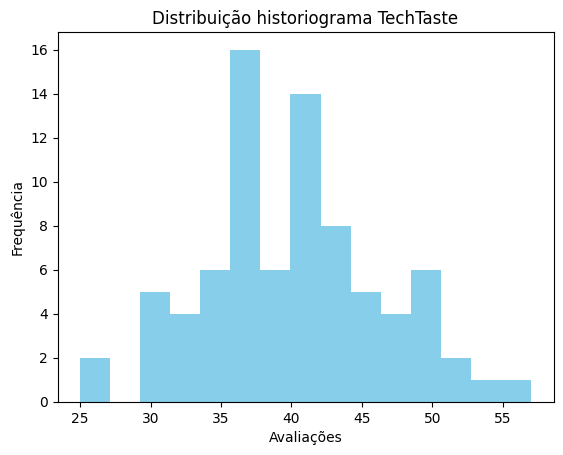

In [55]:
# gráfico histograma
import matplotlib.pyplot as plt

plt.hist(df_techtaste['avaliacoes'], bins=15, color='skyblue')
plt.title('Distribuição historiograma TechTaste')
plt.xlabel('Avaliações')
plt.ylabel('Frequência')
plt.show()

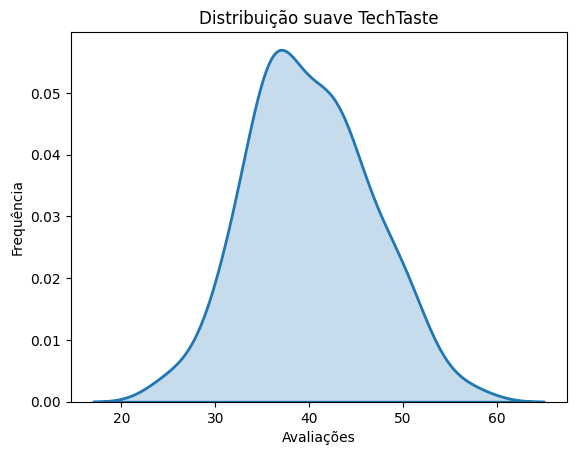

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_techtaste['avaliacoes'], linewidth=2, fill= True)

plt.xlabel('Avaliações')
plt.ylabel('Frequência')
plt.title('Distribuição suave TechTaste')
plt.show()

In [59]:
# intervalo de confiança a 90%
confianca = 0.9

# informações para o IC
media = df_techtaste['avaliacoes'].mean()

# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=erro_padrao_amostral) # variabilidade = erro padrão

print("IC (90%):", intervalo_confianca)

IC (90%): (np.float64(38.84402439920928), np.float64(41.205975600790715))


In [60]:

# e se fosse 95%?
confianca = 0.95

# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra)) # variabilidade = erro padrão

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(38.617780776207844), np.float64(41.43221922379215))
